In [1]:
import numpy as np
import glob
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import tensorflow as tf

In [2]:
today = datetime.date.today()
date = today.strftime("%B%d")
date

'August17'

Load the tensorboard log files into pandas dataframe

In [3]:
# Gather data
data = []
logs = glob.glob(rf".\logs\wheeled_default_beocat_Aug17\*\*")
for log in logs:
    experiment_info = log.split('\\')[-2].split('_')
    algorithm = experiment_info[0]
    st = experiment_info[1]
    # print(log)
    print(log.split('\\'))
    print(experiment_info)

    for e in tf.compat.v1.train.summary_iterator(log):
        for v in e.summary.value:
            if v.tag == 'rollout/ep_rew_mean':
                data.append({
                    'algorithm': algorithm,
                    'set': st,
                    'step': e.step,
                    'reward': v.simple_value
                })
df = pd.DataFrame(data)
df.to_csv(rf"results\wheeled_default_raw_beocat_{date}.csv")
df

['.', 'logs', 'wheeled_default_beocat_Aug17', 'A2C_set1_0', 'events.out.tfevents.1755195776.hero37.640327.0']
['A2C', 'set1', '0']

Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`
['.', 'logs', 'wheeled_default_beocat_Aug17', 'A2C_set1_0', 'events.out.tfevents.1755196631.hero43.1351282.0']
['A2C', 'set1', '0']
['.', 'logs', 'wheeled_default_beocat_Aug17', 'A2C_set2_0', 'events.out.tfevents.1755195776.hero37.640334.0']
['A2C', 'set2', '0']
['.', 'logs', 'wheeled_default_beocat_Aug17', 'A2C_set2_0', 'events.out.tfevents.1755196631.hero43.1351536.0']
['A2C', 'set2', '0']
['.', 'logs', 'wheeled_default_beocat_Aug17', 'A2C_set3_0', 'events.out.tfevents.1755195776.dwarf38.3728625.0']
['A2C', 'set3', '0']
['.', 'logs', 'wheeled_default_beocat_Aug17', 'A2C_set3_0', 'events.out.tfevents.1755196641.dwarf37.1674853.0']
['A2C', 'set3', '0']
['.', 'logs', 'wheeled_default_beocat_Aug17', 'A2C_set4_0', 'events.out.tfevents.1755195776.dwarf38.3728664.0']
['A2C', 's

,algorithm,set,step,reward
0,A2C,set1,500,-97745.710938
1,A2C,set1,1000,-96471.585938
2,A2C,set1,1500,-95711.515625
3,A2C,set1,2000,-93824.820312
4,A2C,set1,2500,-94478.648438
...,...,...,...,...
184130,TRPO,set8,4993024,-14831.700195
184131,TRPO,set8,4995072,-14831.700195
184132,TRPO,set8,4997120,-14831.700195
184133,TRPO,set8,4999168,-15791.000000


In [4]:
df['algorithm'].unique()

array(['A2C', 'ARS', 'CrossQ', 'PPO', 'TQC', 'TRPO'], dtype=object)

In [5]:
# Scaling the rewards for visualization
df['reward_scaled'] = df['reward'] / 1000000
df['reward_scaled'] = df['reward_scaled'].clip(lower=-2)

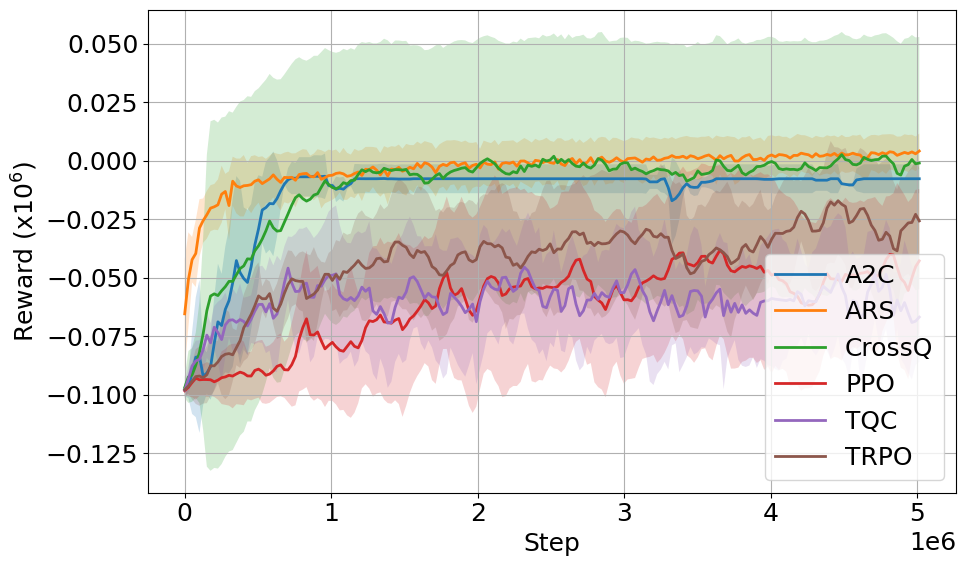

In [6]:
# Define a common x-axis (based on min-max steps across all algorithms)
min_step = df['step'].min()
max_step = df['step'].max()
common_steps = np.linspace(min_step, max_step, 200)

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,6))

# Group by algorithm
for algo, algo_df in df.groupby('algorithm'):
    runs = []

    # For each run (set), interpolate rewards to common steps
    for run_id, run_df in algo_df.groupby('set'):
        x = run_df['step'].values
        y = run_df['reward_scaled'].values
        interp_rewards = np.interp(common_steps, x, y)
        runs.append(interp_rewards)

    runs = np.array(runs)
    mean_rewards = runs.mean(axis=0)
    std_rewards = runs.std(axis=0)

    # Plot with variance shading
    plt.plot(common_steps, mean_rewards, label=algo, linewidth=2)
    plt.fill_between(common_steps, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.2)

plt.xlabel("Step")
plt.ylabel("Reward (x$10^6$)")
# plt.title("RL Algorithms Reward Curves with Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(rf"plots/wheeled_default_beocat_{date}.png")
plt.show()

In [7]:
a2c_df = df[df['algorithm']=='A2C']
ppo_df = df[df['algorithm']=='PPO']
trpo_df = df[df['algorithm']=='TRPO']
ars_df = df[df['algorithm']=='ARS']
crossq_df = df[df['algorithm']=='CrossQ']
tqc_df = df[df['algorithm']=='TQC']


a2c_data = {"Setting": "AB", 
            "Algorithm": "A2C", 
            "Mean": a2c_df['reward'].mean(),
            "SD": a2c_df['reward'].std(),
            "Max": a2c_df['reward'].max(),
            "Range": (a2c_df['reward'].max() - a2c_df['reward'].min())}
ppo_data = {"Setting": "AB", 
            "Algorithm": "PPO", 
            "Mean": ppo_df['reward'].mean(),
            "SD": ppo_df['reward'].std(),
            "Max": ppo_df['reward'].max(),
            "Range": (ppo_df['reward'].max() - ppo_df['reward'].min())}
trpo_data = {"Setting": "AB", 
            "Algorithm": "TRPO", 
            "Mean": trpo_df['reward'].mean(),
            "SD": trpo_df['reward'].std(),
            "Max": trpo_df['reward'].max(),
            "Range": (trpo_df['reward'].max() - trpo_df['reward'].min())}
ars_data = {"Setting": "AB", 
            "Algorithm": "ARS", 
            "Mean": ars_df['reward'].mean(),
            "SD": ars_df['reward'].std(),
            "Max": ars_df['reward'].max(),
            "Range": (ars_df['reward'].max() - ars_df['reward'].min())}
crossq_data = {"Setting": "AB", 
            "Algorithm": "CrossQ", 
            "Mean": crossq_df['reward'].mean(),
            "SD": crossq_df['reward'].std(),
            "Max": crossq_df['reward'].max(),
            "Range": (crossq_df['reward'].max() - crossq_df['reward'].min())}
tqc_data = {"Setting": "AB", 
            "Algorithm": "TQC", 
            "Mean": tqc_df['reward'].mean(),
            "SD": tqc_df['reward'].std(),
            "Max": tqc_df['reward'].max(),
            "Range": (tqc_df['reward'].max() - tqc_df['reward'].min())}


set_tab_df = pd.DataFrame([a2c_data, ppo_data, trpo_data, ars_data, crossq_data, tqc_data])
set_tab_df

,Setting,Algorithm,Mean,SD,Max,Range
0,AB,A2C,-16639.304362,25003.901109,19253.529297,120209.716797
1,AB,PPO,-63006.647233,36231.456837,18938.625000,122545.625000
2,AB,TRPO,-43336.550331,29397.484178,61124.765625,163848.562500
3,AB,ARS,-3461.341724,13888.308514,19592.947266,114719.587891
4,AB,CrossQ,84740.173074,83832.282287,139911.265625,240622.492188
5,AB,TQC,-67277.201872,23495.390192,23463.558594,125124.808594


In [8]:
set_tab_df_sc = set_tab_df.select_dtypes(include='number') / 1000000
set_tab_df_sc.insert(0, 'Setting', set_tab_df['Setting'])
set_tab_df_sc.insert(1, 'Algorithm', set_tab_df['Algorithm'])
set_tab_df_sc

,Setting,Algorithm,Mean,SD,Max,Range
0,AB,A2C,-0.016639,0.025004,0.019254,0.120210
1,AB,PPO,-0.063007,0.036231,0.018939,0.122546
2,AB,TRPO,-0.043337,0.029397,0.061125,0.163849
3,AB,ARS,-0.003461,0.013888,0.019593,0.114720
4,AB,CrossQ,0.084740,0.083832,0.139911,0.240622
5,AB,TQC,-0.067277,0.023495,0.023464,0.125125


In [9]:
set_tab_df_sc.to_csv(rf"results/wheeled_default_beocat_results_{date}.csv")